# Simple scripts to compute walkability features
Francisco Benita     
Padmapriya

Jan 2024

https://osmnx.readthedocs.io/en/stable/user-reference.html     
https://geopandas.org/en/v0.14.1/docs/user_guide.html     


## Contents
* [Data sources](#Data-sources)
* [Extract pedestrian networks](#Extract-pedestrian-networks)
* [Extract population counts](#Extract-popultion-counts)
* [Extract Building counts](#Extract-Building-counts)
* [Extract Elevation data](#Extract-Elevation-data)
* [Five walkability indicators within an isochrone](#Five-walkability-indicators-within-an-isochrone)

# Data sources

**Basemaps** from OpenStreetMaps, **buildings** from Microsoft Building Footprints, and **elevation** from LOS Global Digital Surface Model (AW3D30) can be found int he following links:

* [Jakarta](https://www.dropbox.com/sh/m1j0xy1gpoexqqk/AABW9FEpKLZPVCp4VtJjq6bza?dl=0)
* [Manila](https://www.dropbox.com/scl/fo/7m1xo0igiv5r2g5lmwg21/h?rlkey=ivtgju99wmqufz2grvxa9wsqy&dl=0)
* [Phnom_Penh](https://www.dropbox.com/scl/fo/sjwao4dmjfxccmfqx1wu3/h?rlkey=pk3r08pjas9lvvh279t1t48ho&dl=0)
* [Ho Chi Minh City](https://www.dropbox.com/scl/fo/6qmrn5apmcsqrkcyzsu3c/h?rlkey=x62fr7bomckk1fha7th62lasg&dl=0)
* [Singapore](https://www.dropbox.com/scl/fo/zwmbk8z82qlukspos7tj8/h?rlkey=iw20ma4qekv4243orwpgywr5q&dl=0)


# Extract pedestrian networks

In [ ]:
!pip install gdown==4.6.0

  Attempting uninstall: gdown
    Found existing installation: gdown 5.1.0
    Uninstalling gdown-5.1.0:
      Successfully uninstalled gdown-5.1.0


Let's start by defining the environment, installing and importing libraries

---



In [ ]:
# Define the environment with the required libraries
#!pip install python3-rtree --quiet
!pip install rtree
!pip install osmnx
!pip install geopandas
!pip install geopy
!pip install networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.2/535.2 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.2/107.2 kB 2.0 MB/s eta 0:00:00


In [ ]:
# Import libraries
import osmnx as ox
import matplotlib.pyplot as plt
import geopandas as gpd
import networkx as nx
#from google.colab import files # Download the Saved Files in Google Colab
from shapely.geometry import Point, LineString
import os

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
WALKABILITY_DIR = '/content/drive/My Drive/walkability_project'

# Create the directory if it does not exist
if not os.path.exists(WALKABILITY_DIR):
    os.makedirs(WALKABILITY_DIR)
    print(f"Directory '{WALKABILITY_DIR}' created.")
else:
    print(f"Directory '{WALKABILITY_DIR}' already exists.")

Directory '/content/drive/My Drive/walkability_project' already exists.


The boundary files on .GPKG format of each city of interest can be found in the Basemap foldes of each city. Here is the link to the respective boundary:


* [Jakarta](https://www.dropbox.com/scl/fi/xqlsgatcqw6o28pr544rv/boundary-polygon-land-lvl4.gpkg?rlkey=e3ztzm0zrx5ytc09bda41rft3&dl=0) (Jakarta_all_data\Basemap\data\boundary-polygon-land-lvl4.gpkg)
* [Manila](https://www.dropbox.com/scl/fi/uk80i81irqbls3hh21yc5/boundary-polygon-land-lvl3.gpkg?rlkey=icx9v9iico9p4d3mfrax3x2kf&dl=0) (Manila_all_data\Basemap\data\boundary-polygon-land-lvl3.gpgk)
* [Phnom_Penh](https://www.dropbox.com/scl/fi/j5bt89xrxzj5g1snu2fb9/boundary-polygon-lvl4.gpkg?rlkey=wncvk49b1z39jz5wayys4kh76&dl=0) (Phnom_Penh_all_data\Basemap\data\boundary-polygon-lvl4.gpgk)
* [Ho Chi Minh City](https://www.dropbox.com/scl/fi/292rxvf0i0wgpeqh7tksj/boundary-polygon-land-lvl4.gpkg?rlkey=l3o6jaa136hx1u7k09uhmyr9h&dl=0) (Ho_Chi_Minh_City_all_data\Basemap\data\boundary-polygon-land-lvl4.gpgk)

We next proceed to use that boundary file to extract the pedestrian network

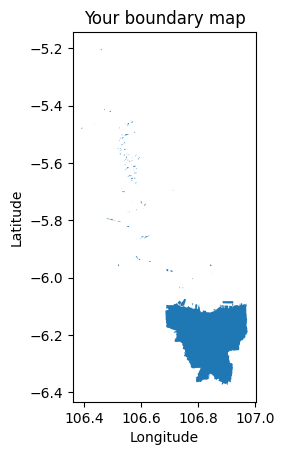

In [ ]:
#### Read the boundary file
def read_boundary_data(url):

    gdf = gpd.read_file(url)

    #### Plot
    # Create a basic plot
    gdf.plot()
    # Add title and labels
    plt.title("Your boundary map")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    # Show the plot
    plt.show()

    return gdf

url = "https://www.dropbox.com/scl/fi/xqlsgatcqw6o28pr544rv/boundary-polygon-land-lvl4.gpkg?rlkey=e3ztzm0zrx5ytc09bda41rft3&dl=1"
gdf = read_boundary_data(url)

0    MULTIPOLYGON (((106.39511 -5.47842, 106.39507 ...
Name: geometry, dtype: geometry


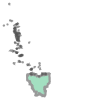

In [ ]:
print(gdf['geometry'])
gdf['geometry'].iloc[0]

In [ ]:
list(gdf.geometry[0].geoms)

for i in range(len(gdf)):
    poly = list(gdf.geometry[i].geoms)
    for j in range(len(poly)):
        print(poly[j])


POLYGON ((106.3951126 -5.4784249, 106.3950723 -5.4784669, 106.395016 -5.4785097, 106.3949208 -5.4785551, 106.3948564 -5.4785911, 106.3948216 -5.4786285, 106.3947907 -5.4786899, 106.3947183 -5.4788701, 106.3945815 -5.479069, 106.3942717 -5.4793827, 106.3940443 -5.4795631, 106.3936079 -5.4798286, 106.3935556 -5.479862, 106.3935321 -5.4798687, 106.393408 -5.4798807, 106.3933899 -5.4798847, 106.3933725 -5.4798927, 106.3930325 -5.4800903, 106.3920522 -5.4803466, 106.3918309 -5.4803693, 106.3916592 -5.4803613, 106.3915169 -5.4803174, 106.3911094 -5.480161, 106.3908961 -5.4800182, 106.3907728 -5.4799034, 106.390644 -5.4797205, 106.3904576 -5.4794695, 106.3904321 -5.4794014, 106.3904241 -5.4791812, 106.3904563 -5.4789943, 106.390528 -5.4788163, 106.3906454 -5.4785764, 106.390758 -5.4784322, 106.3910048 -5.4781706, 106.3911349 -5.4780451, 106.3916163 -5.4777407, 106.3916834 -5.477714, 106.3920347 -5.4776112, 106.3923043 -5.4775271, 106.3924056 -5.4775211, 106.3924907 -5.4775225, 106.3925511 -5.

Refer the link to know more about 'graph_from_polygon'  https://osmnx.readthedocs.io/en/stable/user-reference.html  Various network type supported for download are as below    
network_type (string {"all_private", "all", "bike", "drive", "drive_service", "walk"}) –

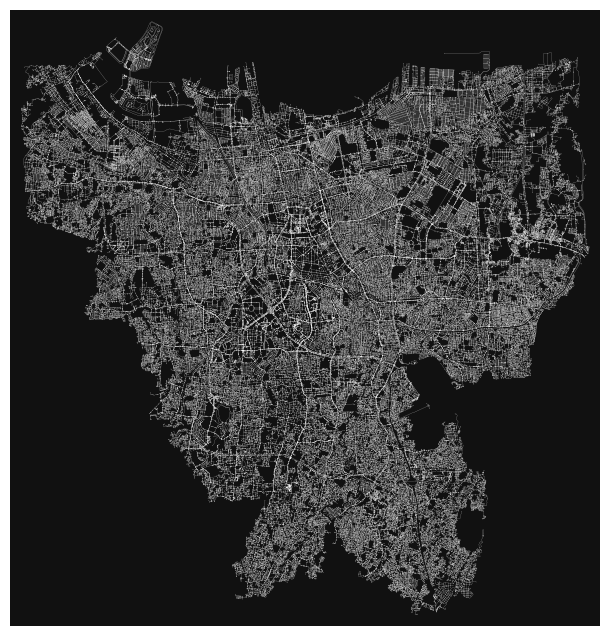

In [ ]:
# Plot the pedestrian network
def extract_pedestrian_network(gdf):
    # Extract the multipolygon geometry from the GeoDataFrame
    p = gdf['geometry'].iloc[0]

    #  Download and extract pedestrian within the boundaries of the multipolygon using OSMnx
    G = ox.graph_from_polygon(p, network_type='walk', simplify=True)

    # Plot the pedestrian network using OSMnx's plot function
    fig, ax = ox.plot_graph(G, edge_linewidth=0.1, node_size=0.1)

    # Uncomment the following line if you want to save the pedestrian network locally in a GeoPackage file
    #Note the below operation takes very long time to execute
    # pedestrian_output_path = WALKABILITY_DIR + '/pedestrian_network.gpkg'
    # ox.save_graph_geopackage(G, pedestrian_output_path)

    # Return the pedestrian network graph
    return G

# Call the function with the GeoDataFrame and the file path for saving the pedestrian network
G = extract_pedestrian_network(gdf)

Let's understand the metadata associated to your pedestrian network.

In [ ]:
def explore_Graph(Sample_G):
    print(type(Sample_G)) #MultiDiGraph
    # Print basic information
    print(f"Number of nodes: {Sample_G.number_of_nodes()}")
    print(f"Number of edges: {Sample_G.number_of_edges()}")

    # Shows the projection epsg:4326
    print(f"Graph attributes: {Sample_G.graph}")


    # Display the first 2 nodes and their attributes
    print("First 2 nodes and their attributes:")
    for node, data in list(Sample_G.nodes(data=True))[:2]:
        print(f"Node {node} attributes:")
        for key, value in data.items():
            print(f"  {key}: {value}")

    # Display the first 2 edges and their attributes
    print("\nFirst 2 edges and their attributes:")
    for u, v, key, data in list(Sample_G.edges(keys=True, data=True))[:2]:
        print(f"Edge ({u}, {v}, {key}) attributes:")
        for key, value in data.items():
            print(f"  {key}: {value}")


explore_Graph(G)

<class 'networkx.classes.multidigraph.MultiDiGraph'>
Number of nodes: 180010
Number of edges: 473326
Graph attributes: {'created_date': '2024-05-24 08:25:15', 'created_with': 'OSMnx 1.9.3', 'crs': 'epsg:4326', 'simplified': True}
First 2 nodes and their attributes:
Node 29938969 attributes:
  y: -6.180894
  x: 106.8230517
  street_count: 3
Node 29938988 attributes:
  y: -6.1828898
  x: 106.8297992
  street_count: 3

First 2 edges and their attributes:
Edge (29938969, 5227846481, 0) attributes:
  osmid: 1263664035
  oneway: False
  lanes: 3
  name: Jalan Mohammad Husni Thamrin
  highway: primary
  width: 16.7
  reversed: False
  length: 8.96
Edge (29938969, 4488259599, 0) attributes:
  osmid: 1252511139
  lanes: 3
  highway: primary
  junction: circular
  oneway: False
  reversed: False
  length: 35.884
  geometry: LINESTRING (106.8230517 -6.180894, 106.8230044 -6.1809222, 106.8229529 -6.1809419, 106.8229112 -6.1809509, 106.8228686 -6.1809544, 106.8228214 -6.1809517, 106.8227894 -6.1809

We can even convert the nodes and edges as dataframes to inspect the Attribute tables:

In [ ]:
# Convert nodes to a GeoPandas DataFrame
nodes_gdf = ox.graph_to_gdfs(G, edges=False)

# Convert edges to a GeoPandas DataFrame
edges_gdf = ox.graph_to_gdfs(G, nodes=False)

# Now you have two GeoPandas DataFrames: nodes_gdf and edges_gdf
# You can inspect their content and attributes
print("Nodes GeoDataFrame:")
print(nodes_gdf.head(2))

print("\nEdges GeoDataFrame:")
edges_gdf.head(2)

Nodes GeoDataFrame:
                 y           x  street_count highway  ref  \
osmid                                                       
29938969 -6.180894  106.823052             3     NaN  NaN   
29938988 -6.182890  106.829799             3     NaN  NaN   

                            geometry  
osmid                                 
29938969  POINT (106.82305 -6.18089)  
29938988  POINT (106.82980 -6.18289)  

Edges GeoDataFrame:


osmid  oneway lanes  \
u        v          key                             
29938969 5227846481 0    1263664035   False     3   
         4488259599 0    1252511139   False     3   

                                                 name  highway width reversed  \
u        v          key                                                         
29938969 5227846481 0    Jalan Mohammad Husni Thamrin  primary  16.7    False   
         4488259599 0                             NaN  primary   NaN    False   

                         length  junction  \
u        v          key                     
29938969 5227846481 0     8.960       NaN   
         4488259599 0    35.884  circular   

                                                                  geometry  \
u        v          key                                                      
29938969 5227846481 0    LINESTRING (106.82305 -6.18089, 106.82304 -6.1...   
         4488259599 0    LINESTRING (106.82305 -6.18089, 106.82300 -6.1...   

                        est_width bridge service access maxspeed  ref tunnel  \
u        v          key                                                        
29938969 5227846481 0         NaN    NaN     NaN    NaN      NaN  NaN    NaN   
         4488259599 0         NaN    NaN     NaN    NaN      NaN  NaN    NaN   

                        area  
u        v          key       
29938969 5227846481 0    NaN  
         4488259599 0    NaN

You can observe that a lot of information is in our graph, such as street length, osmid, maxspeed, etc.

We can describe the pedestrian network, for example, indicating the total number edges and nodes, **network density** (the number of kilometers of network per sq. km), or **intersection density** (number of intersections

In [ ]:
# Number of nodes
num_nodes = len(G.nodes)
# Number of edges
num_edges = len(G.edges)

print(f"Number of nodes in your Pedestrian network: {num_nodes}")
print(f"Number of edges in your Pedestrian network: {num_edges}")

Number of nodes in your Pedestrian network: 180010
Number of edges in your Pedestrian network: 473326


In [ ]:
# Compute the total length of network edges in kmeters

def get_network_length_km(graph):
    # Initialize variables to store total length
    total_length_meters = 0.0

    # Calculate the total length of network edges in meters
    for u, v, data in graph.edges(data=True):
        if 'length' in data:  # Check if 'length' attribute exists
            total_length_meters += data['length']
    # Convert to kilometers
    total_length_km = total_length_meters / 1000

    # Print the total length in kilometers
    print(f"Total length of network edges (km): {total_length_km}")
    return total_length_km


In [ ]:
G_total_length_km=get_network_length_km(G)

Total length of network edges (km): 27253.14899200017


In [ ]:
# Calculate the area of the boundary polygon in square kmeters
def get_network_density(hull_temp,total_length_km):
    hull_temp_gdf = hull_temp.copy()
    hull_gdf_projected = hull_temp_gdf.to_crs(epsg=32748)  # Reproject to EPSG:32748
    area_square_meters = hull_gdf_projected.geometry.area.sum()
    # Convert to square kilometers
    area_square_km = area_square_meters / 1e6  # 1 square kilometer = 1,000,000 square meters
    print(f"Total area of my boundary (sq km): {area_square_km}")

    network_density = total_length_km / area_square_km
    print(f"Total network density (km  of network per sq. km): {network_density}")

    return area_square_km, network_density

In [ ]:
gdf_area_square_km, gdf_network_density=get_network_density(gdf,G_total_length_km)

Total area of my boundary (sq km): 665.0817761561453
Total network density (km  of network per sq. km): 40.97713990828367


Notice that Jakarta covers 661.23 sq. km, so our calculation of 665.5 sq. km is correct. We overestimate the land area due to the multiple islands we have in the north, as shown in the very first plot. So, we can say that Jakarta city has 41 km of pedestrian network for each sq. km of land

In [ ]:
### The code below will check how many nodes are of degree > 2
### The degree of a node is the number of edges connected to the node
def find_intersection_density(graph,sq_km_area):
    intersection_count = 0

    # Iterate through nodes and check if they are intersections (degree > 2)
    for node in graph.nodes():
        if len(list(graph.successors(node))) > 2 or len(list(graph.predecessors(node))) > 2:
            intersection_count += 1

    print(f"Total number of intersection nodes: {intersection_count}")

    intersection_density = intersection_count / sq_km_area
    print(f"Total intersection density (number of intersections network per sq. km): {intersection_density}")

    return intersection_density

In [ ]:
intersection_density = find_intersection_density(G,gdf_area_square_km)

Total number of intersection nodes: 134265
Total intersection density (number of intersections network per sq. km): 201.87743043567892


We can compute many more statistics, but this illustrates the main ideas.

# Extract population counts

The population count file within the boundary of Jakarta can be found here.

[Population_Count_in_Jakarta_Boundary.gpkg](
https://www.dropbox.com/scl/fi/cymqfopbx2df201f00sp8/Population_Count_in_Jakarta_Boundary.gpkg?rlkey=ht2ks6o5qkqsm8wvgw9ljxvbe&dl=0)

* The column 'DN' contains population counts.

In [ ]:
POPULATION_GEOJSON_FILE = 'https://www.dropbox.com/scl/fi/cymqfopbx2df201f00sp8/Population_Count_in_Jakarta_Boundary.gpkg?rlkey=ht2ks6o5qkqsm8wvgw9ljxvbe&dl=1'
# Read the GeoJSON file from the URL
population_gdf = gpd.read_file(POPULATION_GEOJSON_FILE)

In [ ]:
print(f"Total columns: {population_gdf.shape[1]}")\
# Inspect the columns
population_gdf.head(2)

Total columns: 28


,DN,fid_2,NAME,NAME_EN,ADMIN_LVL,OSM_TYPE,OSM_ID,ADMIN_L1D,ADMIN_L1,ADMIN_L2D,...,ADMIN_L6,ADMIN_L7D,ADMIN_L7,ADMIN_L8D,ADMIN_L8,ADMIN_L9D,ADMIN_L9,ADMIN_L10D,ADMIN_L10,geometry
0,139,7682,Daerah Khusus Ibukota Jakarta,Special Capital Region of Jakarta,4,relation,6362934,None,None,None,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((106.46292 -5.20292, 106.46208 ..."
1,140,7682,Daerah Khusus Ibukota Jakarta,Special Capital Region of Jakarta,4,relation,6362934,None,None,None,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((106.46292 -5.20292, 106.46292 ..."


In [ ]:
print(f"Descriptive Statistics for Population counts:\n")
print(population_gdf['DN'].describe())
print(f"\nMissing Values : {population_gdf['DN'].isna().sum()}")

Descriptive Statistics for Population counts:

count    41933.00000
mean       150.25226
std         35.63868
min         62.00000
25%        128.00000
50%        146.00000
75%        166.00000
max        239.00000
Name: DN, dtype: float64

Missing Values : 0


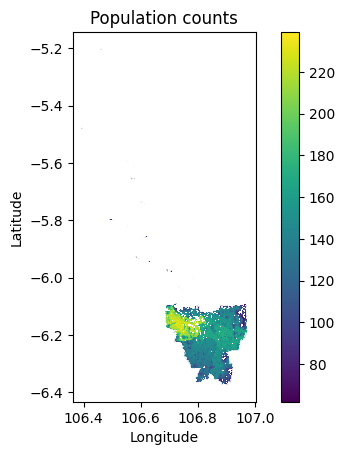

In [ ]:
#### Plot
# Create a plot and specify the column for coloring
population_gdf.plot(column='DN', cmap='viridis', legend=True)

# Add title and labels
plt.title("Population counts")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

We can restrict the plot's x and y limits to focus on Jakarta City only

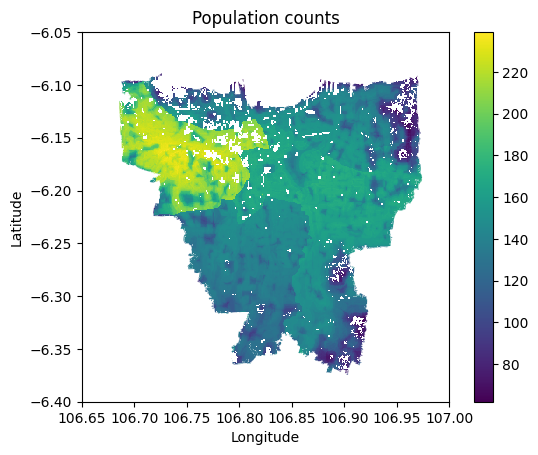

In [ ]:
def plot_Jakarta_metric(sample_gdf,col_name, title, show_legend):
    # Define the x and y limits
    x_min, x_max = 106.65, 107.0
    y_min, y_max = -6.4, -6.05

    # Create a plot and specify the column for coloring
    ax = sample_gdf.plot(column=col_name, legend=show_legend)

    # Set x and y limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Add title and labels
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    # Show the plot
    plt.show()

plot_Jakarta_metric(population_gdf,col_name='DN',title='Population counts',show_legend=True)

# Extract Building counts

The building data file within the boundary of Jakarta can be found here.

[building-polygon.gpkg](
https://drive.google.com/file/d/1wuOhvtKege_gqql9-Xmnwd59wq2NAyWh/view?usp=drive_link)

In [ ]:
import gdown

# Replace 'your_file_id_here' with the actual file ID
file_id = '1wuOhvtKege_gqql9-Xmnwd59wq2NAyWh'

# Construct the download link
file_url = 'https://drive.google.com/uc?id=' + file_id

# Specify the destination path where you want to save the file
output_path = WALKABILITY_DIR + '/building-polygon.gpkg'

# Download the file
gdown.download(file_url, output_path, quiet=False)

# Now, you can read the file using your preferred method
bldg_gdf = gpd.read_file(output_path)
print(bldg_gdf.columns)
print(bldg_gdf.shape)
bldg_gdf['item'] = 1

Downloading...
From: https://drive.google.com/uc?id=1wuOhvtKege_gqql9-Xmnwd59wq2NAyWh
To: /content/drive/My Drive/walkability_project/building-polygon.gpkg
100%|██████████| 385M/385M [00:12<00:00, 30.7MB/s]


Index(['BUILDING', 'ADDR_CITY', 'A_STRT', 'A_SBRB', 'A_HSNMBR', 'A_PLACE',
       'A_PSTCD', 'B_LEVELS', 'NAME', 'NAME_EN', 'NAME_RU', 'OSM_TYPE',
       'OSM_ID', 'geometry'],
      dtype='object')
(1662476, 14)


In [ ]:
building_gdf =  bldg_gdf.copy()
building_gdf_projected = building_gdf.to_crs({'init': 'epsg:3857'})
building_gdf["area"] = building_gdf_projected['geometry'].area/ 10**6
building_gdf.head(2)

/usr/local/lib/python3.10/dist-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


,BUILDING,ADDR_CITY,A_STRT,A_SBRB,A_HSNMBR,A_PLACE,A_PSTCD,B_LEVELS,NAME,NAME_EN,NAME_RU,OSM_TYPE,OSM_ID,geometry,item,area
0,yes,None,None,None,None,None,None,None,None,None,None,relation,96568,"POLYGON ((106.83898 -6.28586, 106.83973 -6.286...",1,0.004166
1,yes,None,None,None,None,None,None,None,None,None,None,relation,2084967,"POLYGON ((106.83839 -6.16689, 106.83868 -6.166...",1,0.001347


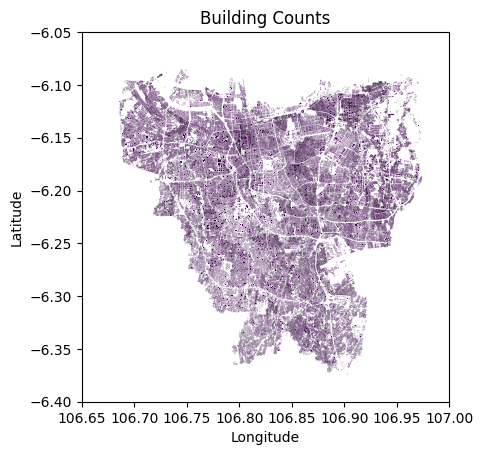

In [ ]:
plot_Jakarta_metric(building_gdf,col_name='item',title='Building Counts',show_legend=False)

# Extract Elevation data

The elevation details file within the boundary of Jakarta can be found here.

[contour_lines.gpkg](
https://www.dropbox.com/scl/fi/h9g2rjc49hbwc3ishf0o5/contour_lines.gpkg?rlkey=pdi83x7l6e3rrfvx8vjoghx98&dl=0)

In [ ]:
import geopandas as gpd
import pandas as pd

def extract_elevation(city_folder_name):
    # Read the GPKG file into a GeoDataFrame
    dropbox_link = "https://www.dropbox.com/scl/fi/h9g2rjc49hbwc3ishf0o5/contour_lines.gpkg?rlkey=pdi83x7l6e3rrfvx8vjoghx98&dl=1"
    elevation_gdf = gpd.read_file(dropbox_link)

    print(elevation_gdf.head(2))

    # Specify the QML attribute(s) you want as a DataFrame
    qml_attribute = 'level'
    df = elevation_gdf[[qml_attribute]]

    # Perform operations on the DataFrame (e.g., df.head() to see the first few rows)
    #elevation_gdf(df.head())

    return elevation_gdf

elevation_gdf = extract_elevation('Jakarta_all_data')
print(elevation_gdf.shape)
elevation_gdf.level.unique(),elevation_gdf.cat.unique()


   cat  level                                           geometry
0    6  -10.0  LINESTRING Z (106.72288 -6.10208 -10.00000, 10...
1    6  -10.0  LINESTRING Z (106.72837 -6.10791 -10.00000, 10...
(1796, 3)


(array([-10.,   0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90.,
        100., 110., 120., 130., 140.]),
 array([ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]))

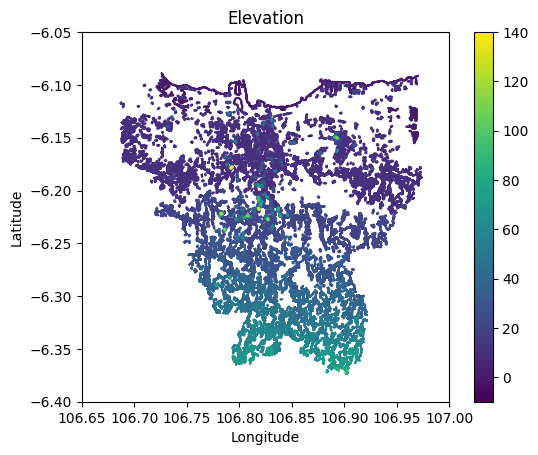

In [ ]:
plot_Jakarta_metric(elevation_gdf,col_name='level',title='Elevation',show_legend=True)

In [ ]:
elevation_gdf['level'].unique()

array([-10.,   0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90.,
       100., 110., 120., 130., 140.])

# Five walkability indicators within an isochrone

We will use four input files: firstly, the pedestrian network extracted in section 3, and secondly, the vectorized file with the population counts in section 4, thirdly the building data extracted in section 5 and finally the elevation data extracted in section 6.

Given a latitude-longitude point of interest, we will construct an isochrone with a 500m radius following the pedestrian network. Then, we will compute the following metrics for that isochrone:

* $I_1$: Total intersection density (number of intersections network per sq. km)
  * It reflects the frequency of street crossings and intersections within a given area, and higher intersection density generally enhances walkability by providing more opportunities for pedestrians to navigate through a neighborhood efficiently and safely.   
      
* $I_2$: Total network density (km  of network per sq. km)
  * It measures the overall length of streets and pathways within a specific area, and greater network density typically correlates with increased walkability as it offers a denser web of interconnected routes, reducing walking distances and promoting pedestrian movement.    
       
* $I_3$: Population density (people per sq. km)
  * It quantifies the number of residents residing within a defined space, is closely linked to walkability as higher population densities support the demand for pedestrian-friendly amenities and services, creating vibrant urban centers with convenient access to daily necessities, transit options, and recreational opportunities.   
       
* $I_4$: Building density (building per sq. km)
  * It measures the concentration of structures within a specified area. Higher building density is associated with increased walkability, as it fosters a mix of land uses and diverse activities. Areas with higher building density tend to have more destinations within close proximity, supporting pedestrian-friendly environments with easy access to shops, services, and cultural amenities. This contributes to a vibrant and active streetscape, encouraging people to walk and explore their surroundings.   
       
* $I_5$: Elevation (slope of the roads per sq. km)
  * Elevation quantifies the slope or incline of the roads within a defined space. It is closely linked to walkability, as roads with more gradual slopes are generally more pedestrian-friendly. Gentle slopes enhance accessibility for people of all abilities, making it easier to walk and navigate the urban environment. In contrast, steep slopes can pose challenges for pedestrians, affecting the overall walkability of an area. Therefore, lower elevation values, indicating flatter terrain, are often associated with better walkability and a more inclusive pedestrian experience    


These five indicators are interrelated and collectively contribute to walkability in urban planning and transportation contexts.

## Constucting an isochrone

The pedestrian network file within the boundary of Jakarta can be found here.

[Jakarta_pedestrian_network.gkpk](https://drive.google.com/file/d/1wuP9SjN6NhZB6EYukRqOBu15Qq7RjuWx/view?usp=drive_link)

In [ ]:
import gdown

# Replace 'your_file_id_here' with the actual file ID
file_id = '1wuP9SjN6NhZB6EYukRqOBu15Qq7RjuWx'

# Construct the download link
file_url = 'https://drive.google.com/uc?id=' + file_id

# Specify the destination path where you want to save the file
pedestrian_output_path = WALKABILITY_DIR + '/pedestrian_network.gpkg'

# Download the file
gdown.download(file_url, pedestrian_output_path, quiet=False)

# Now, you can read the file using your preferred method
def construct_isochrone_graph(url_to_network):
    # load GeoPackage as node/edge GeoDataFrames indexed as described in OSMnx docs
    gdf_nodes = gpd.read_file(url_to_network, layer='nodes').set_index('osmid')
    gdf_edges = gpd.read_file(url_to_network, layer='edges').set_index(['u', 'v', 'key'])
    assert gdf_nodes.index.is_unique and gdf_edges.index.is_unique

    # convert the node/edge GeoDataFrames to a MultiDiGraph
    graph_attrs = {'crs': 'epsg:4326', 'simplified': True}
    G2 = ox.graph_from_gdfs(gdf_nodes, gdf_edges, graph_attrs)

    return G2, gdf_edges,gdf_nodes
G2, gdf_edges,gdf_nodes = construct_isochrone_graph(pedestrian_output_path)

Downloading...
From: https://drive.google.com/uc?id=1wuP9SjN6NhZB6EYukRqOBu15Qq7RjuWx
To: /content/drive/My Drive/walkability_project/pedestrian_network.gpkg
100%|██████████| 87.3M/87.3M [00:00<00:00, 164MB/s]


To compute an isochrone, you wll need a routing algorithm and possibly an isochrone library like `osmnx`, `networkx`, or similar. Let' use `osmnx` and use a point of interest with coordinates `(x,y)=(latitude,longitude)=(-6.153536,06.726189)`. The goal is to extract all the nodes that are reachable from that point of interest within 500m distance.

In [ ]:
from geopy.distance import geodesic

# Provide a point of interest with lat/lon coordinates
poi = (-6.153536, 106.726189)

# Compute the walking isochrone based on distance (500 meters in this example)
def compute_isochrone_for_poi(graph, poi, distance):
    isochrone = nx.MultiDiGraph()
    reachable_nodes = set()

    for node in graph.nodes(data=True):
        node_coords = (node[1]['y'], node[1]['x'])
        if geodesic(poi, node_coords).meters <= distance:
            reachable_nodes.add(node[0])
            # Add nodes to the isochrone
            isochrone.add_node(node[0], **node[1])

    for u, v, key, data in graph.edges(keys=True, data=True):
        if u in reachable_nodes and v in reachable_nodes:
            # Add edges to the isochrone
            isochrone.add_edge(u, v, key=key, **data)

    # Set the CRS for the isochrone (same as G2)
    isochrone.graph["crs"] = graph.graph["crs"]

    return isochrone

isochrone = compute_isochrone_for_poi(G2, poi, distance=500)

Let's understand the metadata associated to your sub-network within the isochrone.

In [ ]:
explore_Graph(isochrone)

<class 'networkx.classes.multidigraph.MultiDiGraph'>
Number of nodes: 222
Number of edges: 274
Graph attributes: {'crs': 'epsg:4326'}
First 2 nodes and their attributes:
Node 316839679 attributes:
  y: -6.1517122
  x: 106.7271371
  street_count: 3
  highway: 
  ref: 
Node 409554591 attributes:
  y: -6.1517211
  x: 106.7266328
  street_count: 3
  highway: 
  ref: 

First 2 edges and their attributes:
Edge (316839679, 409554591, 0) attributes:
  osmid: 34912328
  lanes: 1
  highway: residential
  junction: 
  oneway: False
  reversed: False
  length: 55.762
  from: 409554591
  to: 316839679
  name: Jalan EE
  width: 5
  est_width: 
  bridge: 
  service: 
  access: 
  maxspeed: 
  ref: 
  tunnel: 
  area: 
  geometry: LINESTRING (106.7266328 -6.1517211, 106.7271371 -6.1517122)
Edge (316839679, 6487743153, 0) attributes:
  osmid: 533745021
  lanes: 2
  highway: primary
  junction: 
  oneway: False
  reversed: False
  length: 15.601
  from: 6487743153
  to: 316839679
  name: Jalan Syekh Jun

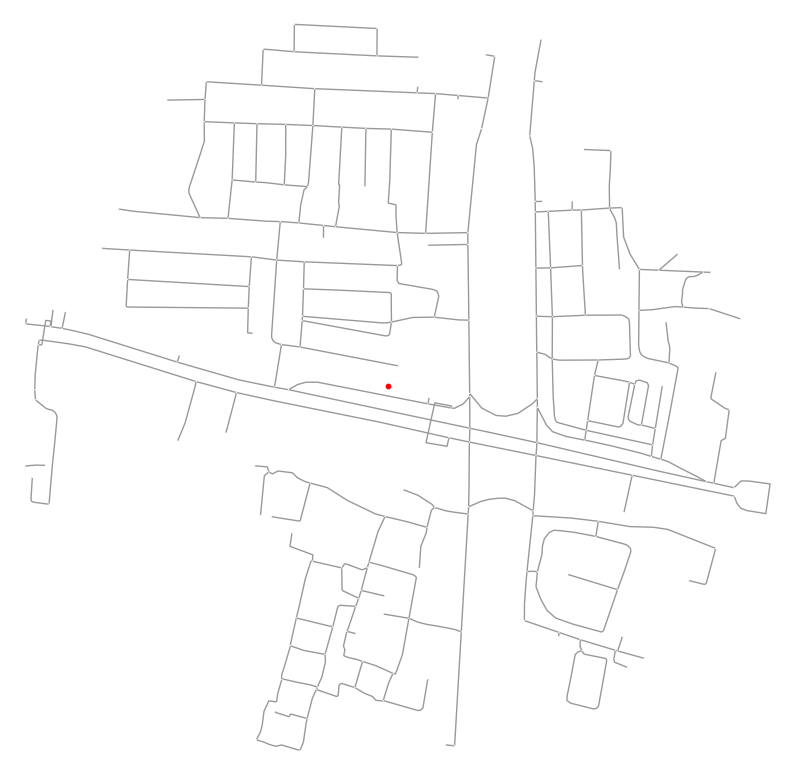

In [ ]:
import matplotlib.pyplot as plt
def plot_isochrone(isochrone):
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot the isochrone edges
    ox.plot_graph(isochrone, ax=ax, edge_linewidth=1, node_size=1, show=False)

    # Add the 'poi' in red
    ax.scatter(poi[1], poi[0], c='red', label='point of interest', s=10)

    plt.show()

plot_isochrone(isochrone)

The next step is to compute the envelope of a set of points in a plane, which generates a convex hull.

In [ ]:
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon

def generate_convex_hull_for_iscochrone(isochrone):
    # Create a list to store the coordinates of nodes in the isochrone
    node_coords = []

    for node, data in isochrone.nodes(data=True):
        node_coords.append((data['x'], data['y']))

    # Compute the convex hull of the node coordinates
    hull = ConvexHull(node_coords)

    # Extract the convex hull vertices
    hull_vertices = [node_coords[i] for i in hull.vertices]

    # Create a Polygon from the convex hull vertices
    convex_hull_polygon = Polygon(hull_vertices)

    # Create a GeoDataFrame with the convex hull polygon
    hull_gdf = gpd.GeoDataFrame({'geometry': [convex_hull_polygon]}, crs=isochrone.graph["crs"])

    return hull_gdf

# Now you have a GeoDataFrame 'hull_gdf' containing the solid convex hull polygon
hull_gdf =  generate_convex_hull_for_iscochrone(isochrone)

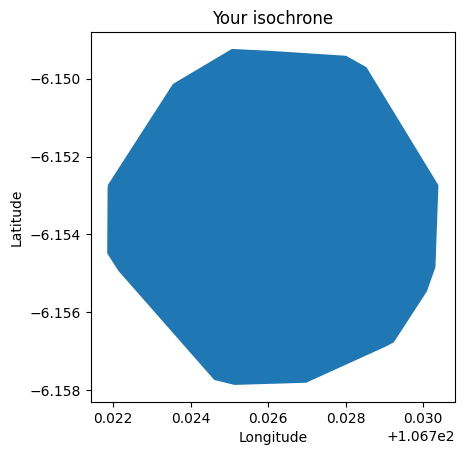

In [ ]:
def plot_hull_for_iscochrone(hull_gdf):
    #### Plot
    # Create a basic plot
    hull_gdf.plot()
    # Add title and labels
    plt.title("Your isochrone")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    # Show the plot
    plt.show()
    hull_gdf.columns

plot_hull_for_iscochrone(hull_gdf)

<Axes: >

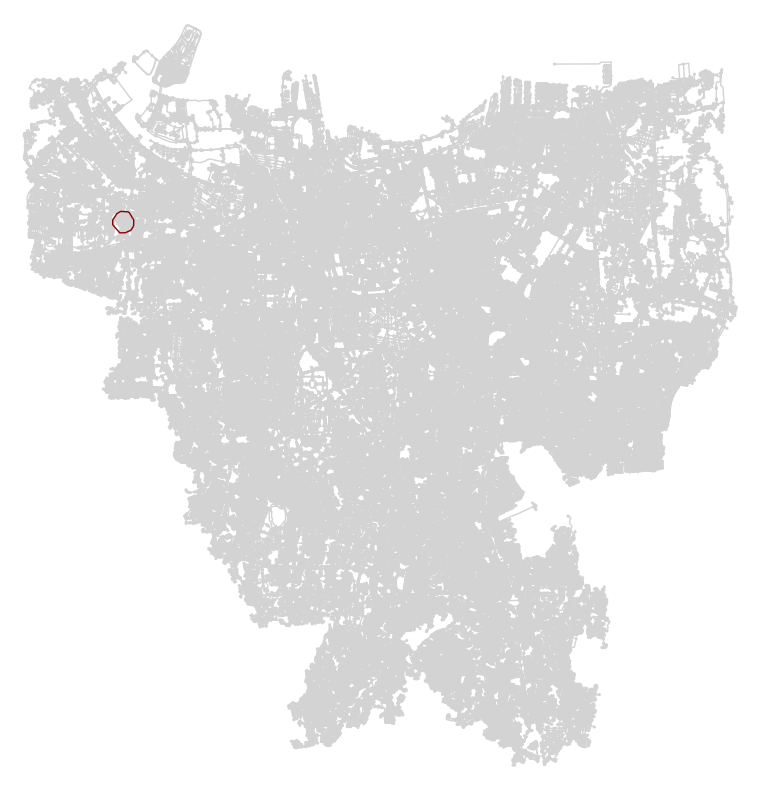

In [ ]:
# Locating isochone poi over the pedestrian network
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the original graph with lighter color
ox.plot_graph(G2, ax=ax, node_color='lightgray', node_size=5, edge_color='lightgray', show=False)

# Plot the convex hull over the original graph with darker color
hull_gdf.plot(ax=ax, edgecolor='darkred', facecolor='none')


## $I_1$: Total intersection density (number of intersections network per sq. km) and $I_2$: Total network density (km of network per sq. km)

Given that our sub-graph containing the pedestrian netowrk is a `MultiDiGraph` and the isocrone is a GeoDataFrame, we can compute $I_1$ anf $I_2$ in the same fashion as we did it at the begining of the tutorial using the whole network of Jakarta city and the whole boundary.

In [ ]:
total_length_km=get_network_length_km(isochrone)

Total length of network edges (km): 16.645039999999995


In [ ]:
print("I2")
area_square_km, network_density=get_network_density(hull_gdf,total_length_km)

I2
Total area of my boundary (sq km): 0.6936279316182797
Total network density (km  of network per sq. km): 23.9970728415824


In [ ]:
print("I1")
intersection_density=find_intersection_density(isochrone,area_square_km)

I1
Total number of intersection nodes: 60
Total intersection density (number of intersections network per sq. km): 86.50170684449809


## $I_3$ Population density (people per sq. km)

In [ ]:
# Define the x and y limits

def plot_overlap(geo_df_data,hull_gdf_sample, column_interested, insert_legend):
    x_mins, x_maxs = 106.720, 106.732
    y_mins, y_maxs = -6.158, -6.149

    # Create a new figure
    fig, ax = plt.subplots(figsize=(10, 10))
    # Set x and y limits
    ax.set_xlim(x_mins, x_maxs)
    ax.set_ylim(y_mins, y_maxs)

    # Plot the population counts on the axes
    geo_df_data.plot(ax=ax, column=column_interested, cmap='viridis', legend=insert_legend)

    # Plot the convex-hull (i.e., isochrone) on the same axes
    hull_gdf_sample.plot(ax=ax, facecolor='none', edgecolor='black', lw=1)

    # Add a legend to distinguish between the two datasets
    ax.legend()

    # Optionally, you can set the title and labels
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    # Display the plot
    plt.show()


def compute_density_overlap(geo_df, hull_gdf_sample):
    # Calculate the spatial overlap
    overlap_gdf = gpd.overlay(geo_df, hull_gdf_sample, how='intersection')
    # Count the number of rows in the overlapping GeoDataFrame
    overlap_count = len(overlap_gdf)
    print(f"Number of overlapping rows: {overlap_count}")

    #print(overlap_gdf.DN)
    # Plot
    #ax = hull_gdf_sample.plot(facecolor='none', edgecolor='black', lw=1)
    # Plot the overlapping geometries on the same plot
    #overlap_gdf.plot(ax=ax, color='red', alpha=0.5)
    # Save the plot
    #plt.savefig('Overlap.png', column='DN', cmap='viridis', legend=True)
    # Show the plot
    #plt.show()

    return overlap_gdf, overlap_count


def get_total_count(overlap_gdf,area_square_km, item_of_interest,  column_interested='DN'):
    total_population = overlap_gdf[column_interested].sum()
    area_square_km
    print(f"Total {item_of_interest}: {total_population}")
    print('Total area:', area_square_km)

    print(f"{item_of_interest} density (per sq. km)): {total_population/area_square_km}")

We already know the total area of the isocrhone of interest, which is 0.6936 sq. km. We now need to observe how many people is living there in the 100m $\times$ 100 grid cells. We can first plot the population counts to have an idea of the desired result.

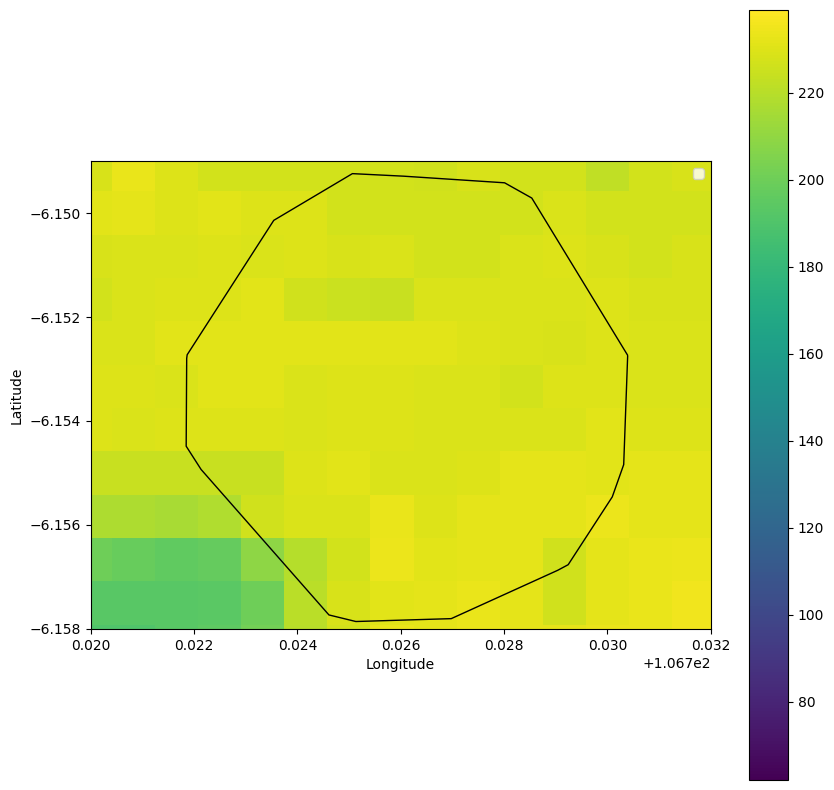

In [ ]:
plot_overlap(population_gdf,hull_gdf, column_interested='DN',insert_legend=True)

Let's now proceed to conduct an **overlap** between the two geodataframes

In [ ]:
overlap_gdf, overlap_count = compute_density_overlap(population_gdf, hull_gdf)

Number of overlapping rows: 47


In [ ]:
get_total_count(overlap_gdf,area_square_km,  column_interested='DN',item_of_interest='population')

Total population: 10722
Total area: 0.6936279316182797
population density (per sq. km)): 15457.855013111808


We observe that there are **47** grid cells with population counts inside our isochrone of interest. The attribute 'DN'shows the number of people. We can proceed to simply sum the total number of people in column 'DN', which will result in the total number of people. Furthermore, since we already know that this isochrone has an area of 0.6936 sq. km, we can also compute $I_3$ Population density (people per sq. km)

## $I_4$ Building density (Buildings Proportion)

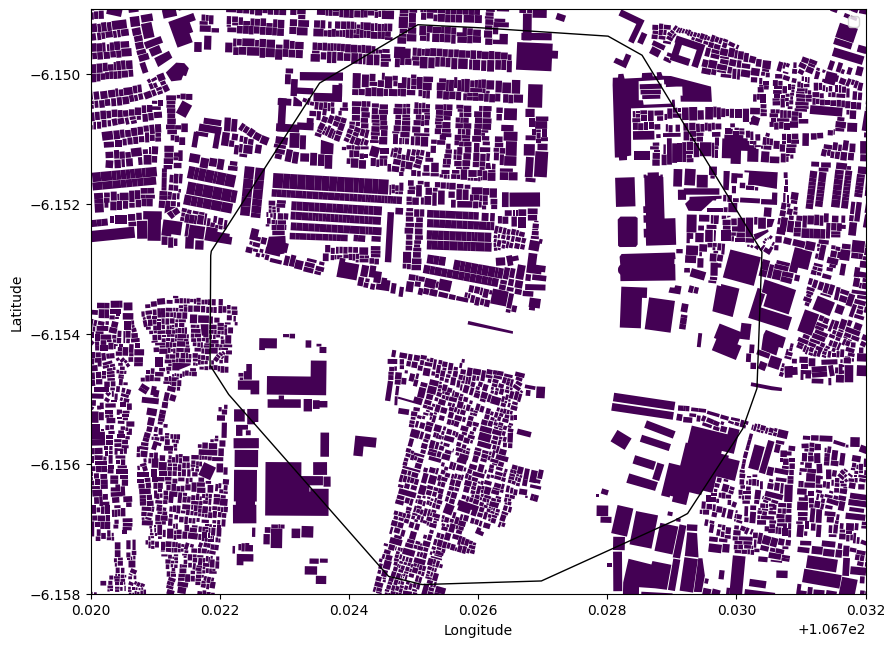

In [ ]:
plot_overlap(building_gdf,hull_gdf,  column_interested='item',insert_legend=False)

In [ ]:
overlap_gdf_bldg, overlap_bldg_count = compute_density_overlap(building_gdf, hull_gdf)

Number of overlapping rows: 1776


We observe that there are 1776 buildings inside our isochrone of interest. Next, we can also compute $I_4$ Building density (building per sq. km)

In [ ]:
get_total_count(overlap_gdf_bldg,area_square_km,  column_interested='area',item_of_interest='building')

Total building: 0.26955932088651346
Total area: 0.6936279316182797
building density (per sq. km)): 0.38862235587545296


## $I_5$ Elevation Changes

Next, We now need to observe the elevation range in the isochrone.

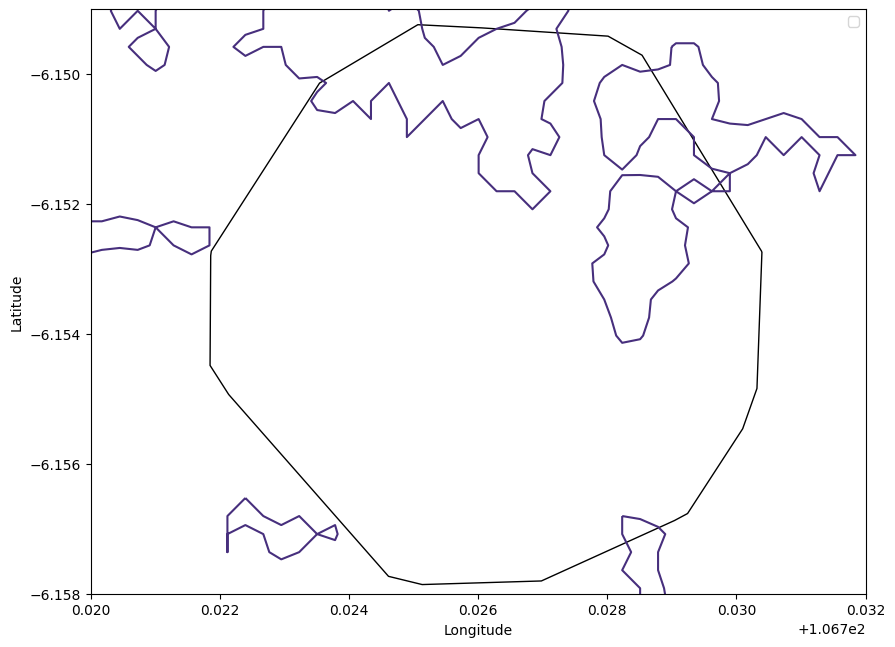

In [ ]:
plot_overlap(elevation_gdf,hull_gdf,  column_interested='level',insert_legend=False)

In [ ]:
overlap_gdf_elv, overlap_elv_count = compute_density_overlap(elevation_gdf, hull_gdf)

def get_total_count_(overlap_gdf,area_square_km, item_of_interest,  column_interested='DN'):

    max_elevation = overlap_gdf[column_interested].max()
    min_elevation = overlap_gdf[column_interested].min()

    print(f"max_elevation. : {max_elevation}")
    print(f"min_elevation. : {min_elevation}")

    elevation_diff = max_elevation - min_elevation
    print(f"Avg. {item_of_interest}: {elevation_diff}")
    print('Total area:', area_square_km)

    print(f"{item_of_interest} (per sq. km)): {elevation_diff/area_square_km}")
get_total_count_(overlap_gdf_elv,area_square_km,  column_interested='level',item_of_interest='elevation')

Number of overlapping rows: 3
max_elevation. : 10.0
min_elevation. : 10.0
Avg. elevation: 0.0
Total area: 0.6936279316182797
elevation (per sq. km)): 0.0


## Summary

In summary, we have shown how to use geo-spatial data to compute 5 walkability indicators. For a given  point of interest, say, `(x,y)=(latitude,longitude)=(-6.153536,06.726189)`, we have computed:


1. An isochrone illustrating all routes along the pedestrian network within a 500m distance.
  * Extract all the reachable nodes.
  * Extract all the edges within these reachable nodes.
  * Create a convex hull (although a concave hull would be better but is harder to compute).
2. Compute network connectivity indicators within the isochrone, such as network density or intersection density.
  * We need to carefully calculate the total area (in sq. km) of the isochrone.
3. Overlap between the isochrone boundary and the population count file.
  * This is an interesting operation that allows us to extract additional information from raster files. We could do the same for a raster file with greenery/vegetation data.
4. Building Density: Calculate the density of buildings within the isochrone area (e.g., the proportion of the isochrone covered by buildings). High building density can indicate a vibrant, walkable urban environment.     
          
5. Elevation Changes: Analyze elevation raster data to identify steep slopes and grade changes. Flat terrain is more pedestrian-friendly.   
  
  Next steps:
1. Using the isochrone as input, we should calculate more walkability indicators, such as:
  * Walking distance from the center of the isochrone (e.g., poi) to the nearest park.
2. All the tasks  above are performed within a single isochrone. However, we can extend the analysis even further by:
  * Computing isochrones for the entire city of Jakarta. This can be achieved by inserting a grid-cell of centroids. Then, using a for loop, we can cover the city with isochrones, and for each of them, calculate the walkability indicators.
  * We even have the same data (e.g., street network, basemap, building data, etc.) for 5 cities. We can compute walkability metrics for all these cities.
